# 00_01 — Seleção de Features para Análise FFT

**Pipeline:** `fft_ingestion`  
**Kedro node:** `load_fft_flights_node`  
**Output catalog:** `fft_ready_flights` → `data/02_intermediate/fft_ready/`

---

## Contexto

Este notebook demonstra o fluxo da pipeline `fft_ingestion`, variante focada da `data_ingestion` (notebook `00_00`).

A `data_ingestion` preserva todos os sinais informativos (~50–60 colunas após filtragem de ruído).  
A `fft_ingestion` aplica um critério mais restrito: **retém apenas os sinais que possuem mecanismo
físico direto de periodicidade ligada ao motor**, mais uma exceção explícita descrita abaixo.

### Critério de inclusão

Um sinal é incluído se **o motor cria uma componente periódica nesse sinal** e essa periodicidade
muda de forma detectável na falha — **mais uma exceção**: `altitude`, incluída como única feature
time-domain para complementar a assinatura espectral com a tendência de descida na falha.

| Sinal | Mecanismo / justificativa de inclusão | Faixa de frequência |
|---|---|---|
| IMU acelerômetro x/y/z | Vibração mecânica do motor/hélice na estrutura | 10–200 Hz |
| Magnetômetro x/y/z | Campo EM do enrolamento + rotação das pás | f = RPM/60 |
| Airspeed medido | Ripple de empuxo → oscilação periódica na velocidade do ar | 0.5–5 Hz |
| **Altitude** | **Única feature time-domain: declínio monotônico na falha** (sem motor, a aeronave plana e perde altitude) | — |

### O que foi excluído e por quê

| Sinal | Razão da exclusão |
|---|---|
| Corrente de bateria | **Constante ao longo do tempo** neste dataset — sem variação útil para o modelo |
| `energy_specific` | Indicador time-domain derivado; sem periodicidade de motor |
| Velocidade GPS, `glide_ratio`, `energy_rate` | Derivados úteis para rolling stats, mas sem assinatura espectral do motor |
| Throttle do autopiloto | Mudança de estado (*step*), não periódica — informativo no tempo, não no espectro |
| Pitch/roll cmd/meas, heading | Sinais de navegação/controle sem ligação com a frequência de rotação do motor |

> **Para rodar toda a pipeline no Kedro:** `kedro run --pipeline=fft_ingestion`

## Imports e parâmetros

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import periodogram

# Funções da pipeline fft_ingestion — as mesmas que o Kedro executa em produção
from aeroespacial_2.pipelines.fft_ingestion.nodes import (
    FFT_RELEVANT_PATTERNS,
    select_fft_features,
)

# Funções reutilizadas de data_ingestion
from aeroespacial_2.pipelines.data_ingestion.nodes import (
    filter_noise_columns,
    merge_flight_csvs,
)

# Parâmetros espelhando conf/base/parameters.yml
FLIGHT_DIR = "../../data/01_raw/processed/carbonZ_2018-07-18-15-53-31_1_engine_failure"
IMU_SOURCE_TO_DISCARD = "imu-data_raw"

## Passo 1 — Merge dos tópicos ROS

Idêntico ao `00_00`: carrega todos os `.csv` da pasta de voo, alinha temporalmente via `merge_asof`
e normaliza o tempo para segundos.

In [2]:
df_merged = merge_flight_csvs(FLIGHT_DIR)

print(f"Shape após merge: {df_merged.shape}")
print(f"Tempo: {df_merged['%time'].min():.2f}s → {df_merged['%time'].max():.2f}s")
df_merged.head(3)

Shape após merge: (26183, 531)
Tempo: 0.04s → 132.39s


,%time,carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.header.seq,carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.header.stamp,carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.header.frame_id,carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.framing_status,carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.magic,carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.len,carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.incompat_flags,carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.compat_flags,carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.seq,...,carbonZ_2018-07-18-15-53-31_1_engine_failure-diagnostics_field.status3.values21.value,carbonZ_2018-07-18-15-53-31_1_engine_failure-diagnostics_field.status3.values22.value,carbonZ_2018-07-18-15-53-31_1_engine_failure-diagnostics_field.status3.values23.value,carbonZ_2018-07-18-15-53-31_1_engine_failure-diagnostics_field.status3.values24.value,carbonZ_2018-07-18-15-53-31_1_engine_failure-diagnostics_field.status3.values25.value,carbonZ_2018-07-18-15-53-31_1_engine_failure-diagnostics_field.status4.level,carbonZ_2018-07-18-15-53-31_1_engine_failure-diagnostics_field.status4.values0.value,carbonZ_2018-07-18-15-53-31_1_engine_failure-diagnostics_field.status4.values1.value,carbonZ_2018-07-18-15-53-31_1_engine_failure-diagnostics_field.status4.values2.value,carbonZ_2018-07-18-15-53-31_1_engine_failure-failure_status-engines_field.data
0,0.040093,35100,1531943810859778567,0.0,1,254,51,0,0,199,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.044453,35101,1531943810863587190,0.0,1,254,31,0,0,200,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.045652,35102,1531943810866078390,0.0,1,254,6,0,0,201,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Passo 2 — Filtragem de colunas de ruído

Idêntico ao `00_00`: remove metadados ROS (headers, covariâncias, checksums), canais RC,
flags de estado MAVLink e outras colunas não informativas.

In [3]:
df_preprocessed = filter_noise_columns(df_merged, imu_source_to_discard=IMU_SOURCE_TO_DISCARD)

print(f"Colunas antes:  {df_merged.shape[1]}")
print(f"Colunas depois: {df_preprocessed.shape[1]}")
print(f"Removidas:      {df_merged.shape[1] - df_preprocessed.shape[1]}")

Colunas antes:  531
Colunas depois: 107
Removidas:      424


## Passo 3 — Análise de relevância espectral

Inspecionamos o conteúdo espectral das colunas disponíveis para justificar a seleção.

### Classificação das colunas disponíveis

In [4]:
def classify_columns(df: pd.DataFrame, patterns: list[str]) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        if col == "%time":
            continue
        matched = [p for p in patterns if p in col]
        rows.append({
            "coluna": col,
            "selecionada": bool(matched),
            "padrão_correspondente": matched[0] if matched else "—",
            "nome_curto": col.split("_field.")[-1].split("-")[-1],
        })
    return pd.DataFrame(rows)


df_class = classify_columns(df_preprocessed, FFT_RELEVANT_PATTERNS)

print(f"Total de colunas (sem %time): {len(df_class)}")
print(f"  → Selecionadas: {df_class['selecionada'].sum()}")
print(f"  → Rejeitadas:   {(~df_class['selecionada']).sum()}")
print()
print("=== Colunas SELECIONADAS e padrão correspondente ===")
display(df_class[df_class["selecionada"]][["nome_curto", "padrão_correspondente"]].reset_index(drop=True))

Total de colunas (sem %time): 106
  → Selecionadas: 10
  → Rejeitadas:   96

=== Colunas SELECIONADAS e padrão correspondente ===


,nome_curto,padrão_correspondente
0,data,failure_status
1,altitude,global_field.altitude
2,linear_acceleration.x,imu-data_field.linear_acceleration
3,linear_acceleration.y,imu-data_field.linear_acceleration
4,linear_acceleration.z,imu-data_field.linear_acceleration
5,x,mag_field.magnetic
6,y,mag_field.magnetic
7,z,mag_field.magnetic
8,measured,airspeed_field.measured
9,altitude,global_field.altitude


In [5]:
print("=== Colunas REJEITADAS ===")
display(df_class[~df_class["selecionada"]][["nome_curto"]].reset_index(drop=True))

=== Colunas REJEITADAS ===


,nome_curto
0,x
1,y
2,z
3,x
4,y
...,...
91,heading
92,throttle
93,twist.linear.x
94,twist.linear.y


### Visualização: domínio do tempo e domínio da frequência

Para cada sinal, plotamos série temporal e PSD (densidade espectral de potência).

Sinais com FFT genuinamente relevante para o motor apresentam **picos espectrais associados
à frequência de rotação** e **mudança visível no espectro na falha**.

In [6]:
def find_col(df: pd.DataFrame, pattern: str) -> str | None:
    """Retorna a primeira coluna que contém o padrão, ou None."""
    matches = [c for c in df.columns if pattern in c]
    return matches[0] if matches else None


def plot_time_and_fft(
    df: pd.DataFrame,
    col: str,
    label: str,
    ax_time: plt.Axes,
    ax_fft: plt.Axes,
    failure_time: float | None = None,
    color: str = "tab:blue",
) -> None:
    """Plota série temporal e PSD de uma coluna."""
    time = df["%time"].values
    signal = df[col].ffill().fillna(0).values.astype(float)
    dt = np.median(np.diff(time))
    fs = 1.0 / max(dt, 1e-6)

    ax_time.plot(time, signal, linewidth=0.7, color=color)
    if failure_time is not None:
        ax_time.axvline(failure_time, color="red", linestyle="--", linewidth=1.2, label="falha")
    ax_time.set_ylabel(label, fontsize=8)
    ax_time.grid(True, alpha=0.3)
    ax_time.set_xlabel("Tempo (s)")

    freqs, psd = periodogram(signal - signal.mean(), fs=fs)
    max_freq = min(fs / 4, 50.0)
    mask = (freqs > 0) & (freqs <= max_freq)
    ax_fft.semilogy(freqs[mask], psd[mask], linewidth=0.8, color="tab:orange")
    ax_fft.set_xlabel("Frequência (Hz)")
    ax_fft.set_ylabel("PSD")
    ax_fft.grid(True, alpha=0.3)
    ax_fft.set_title(f"Espectro — {label}", fontsize=8)

In [7]:
# Identifica o instante de falha
failure_col = find_col(df_preprocessed, "failure_status")
failure_time = None
if failure_col:
    fault_mask = df_preprocessed[failure_col] > 0.5
    if fault_mask.any():
        failure_time = df_preprocessed.loc[fault_mask, "%time"].min()
        print(f"Evento de falha detectado em t = {failure_time:.2f} s")
    else:
        print("Nenhum evento de falha neste voo (failure_status sempre 0).")
else:
    print("Coluna failure_status não encontrada.")

Evento de falha detectado em t = 116.31 s


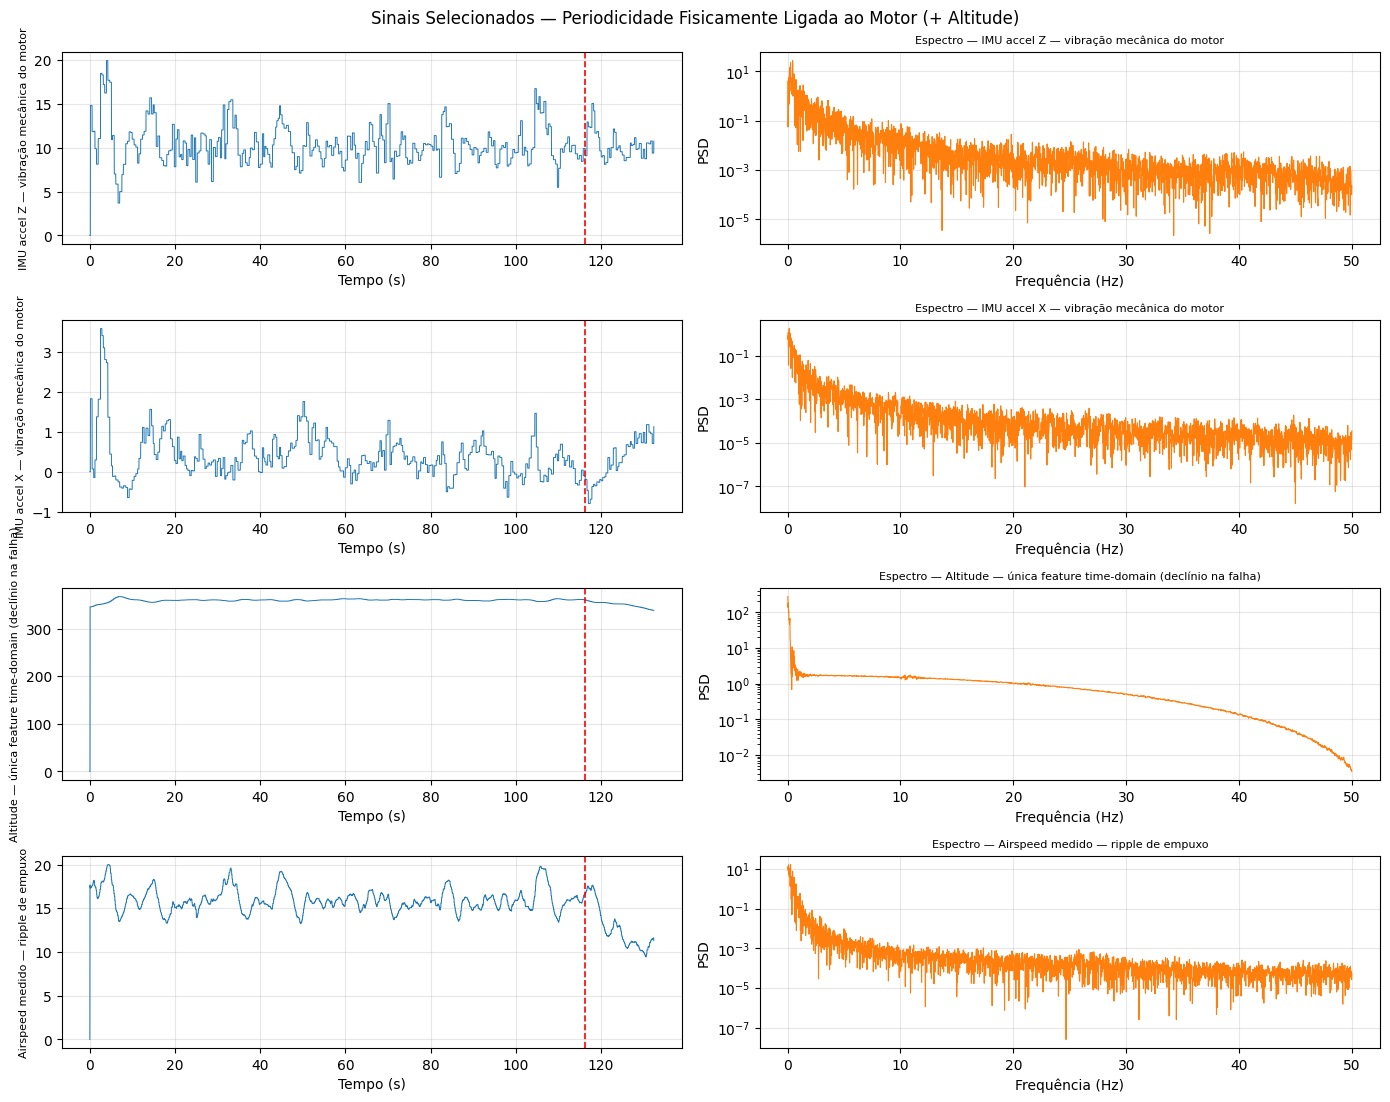

In [8]:
# ── Sinais SELECIONADOS: possuem mecanismo físico de periodicidade ligado ao motor ───
# Altitude é a exceção: única feature time-domain incluída (declínio na falha).
selected_examples = [
    (find_col(df_preprocessed, "linear_acceleration.z"),  "IMU accel Z — vibração mecânica do motor"),
    (find_col(df_preprocessed, "linear_acceleration.x"),  "IMU accel X — vibração mecânica do motor"),
    (find_col(df_preprocessed, "mag_field.magnetic.z"),   "Magnetômetro Z — assinatura EM do motor"),
    (find_col(df_preprocessed, "global_field.altitude"),  "Altitude — única feature time-domain (declínio na falha)"),
    (find_col(df_preprocessed, "airspeed_field.measured"),"Airspeed medido — ripple de empuxo"),
]
selected_examples = [(col, lbl) for col, lbl in selected_examples if col is not None]

n = len(selected_examples)
fig, axes = plt.subplots(n, 2, figsize=(14, 2.8 * n), sharex=False)
fig.suptitle("Sinais Selecionados — Periodicidade Fisicamente Ligada ao Motor (+ Altitude)", fontsize=12)

for i, (col, label) in enumerate(selected_examples):
    plot_time_and_fft(
        df_preprocessed, col, label,
        ax_time=axes[i, 0], ax_fft=axes[i, 1],
        failure_time=failure_time,
        color="tab:blue",
    )

plt.tight_layout()
plt.show()

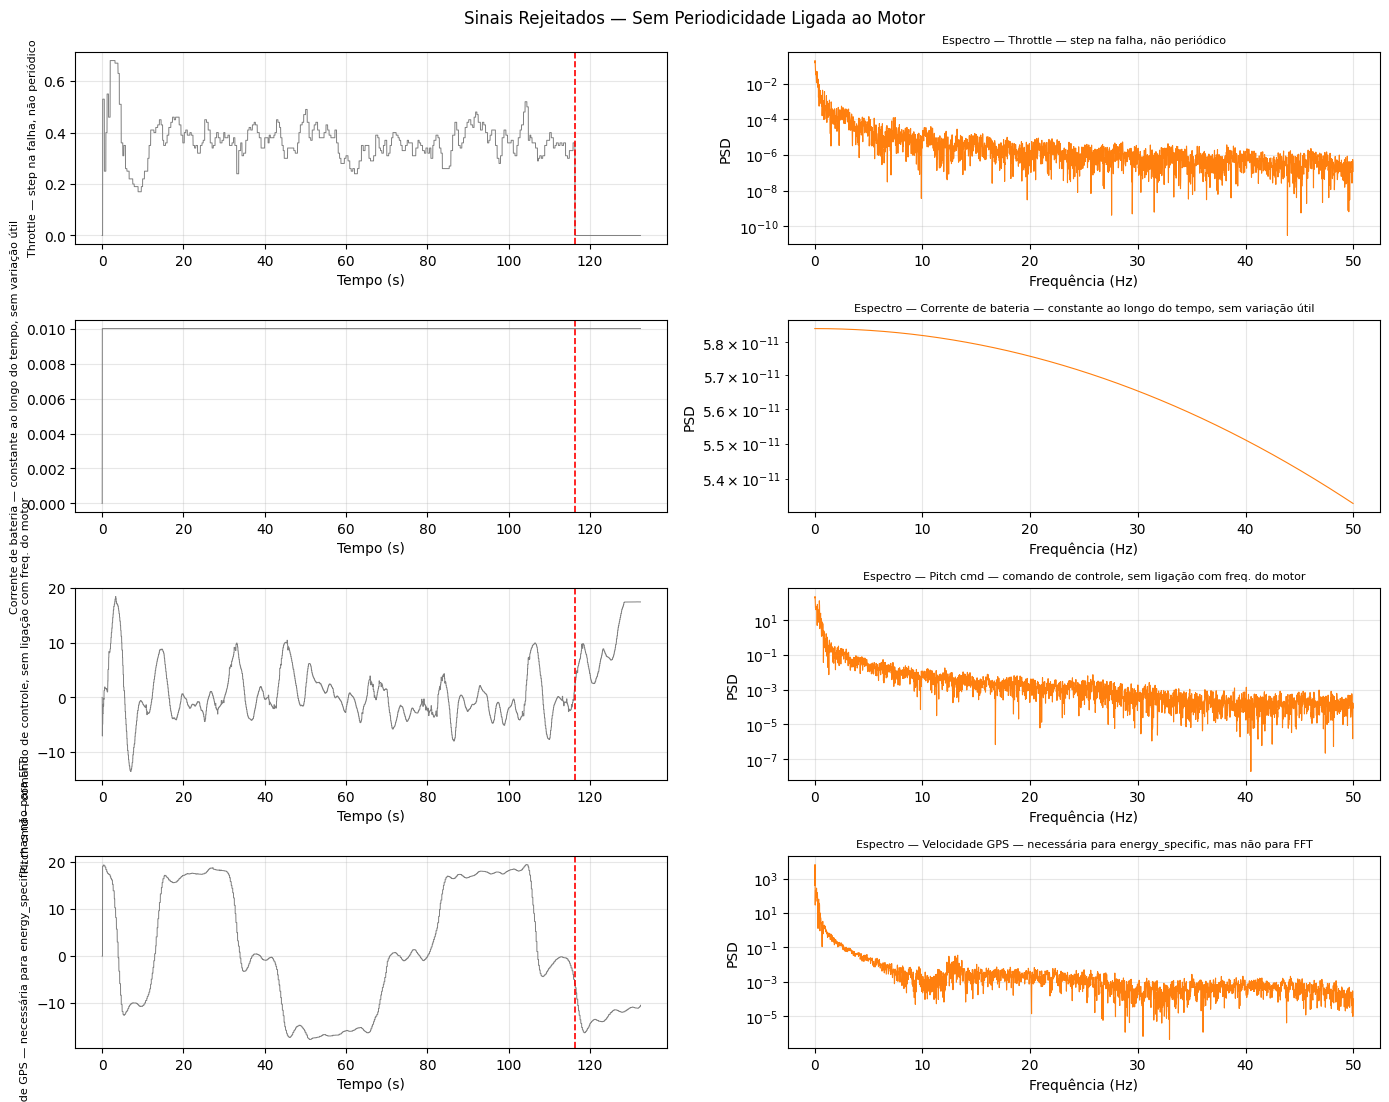

In [9]:
# ── Sinais REJEITADOS: sem periodicidade ligada ao motor ─────────────────────────────
#
# Exemplos de cada categoria rejeitada para contraste:
#   - Navegação/controle (step changes ou tendências lentas)
#   - Corrente de bateria (constante ao longo do tempo — sem variação útil)
#   - Throttle (step na falha, não periódico)
rejected_examples = [
    (find_col(df_preprocessed, "vfr_hud_field.throttle"),
     "Throttle — step na falha, não periódico"),
    (find_col(df_preprocessed, "battery_field.current"),
     "Corrente de bateria — constante ao longo do tempo, sem variação útil"),
    (find_col(df_preprocessed, "pitch_field.commanded") or find_col(df_preprocessed, "pitch_field"),
     "Pitch cmd — comando de controle, sem ligação com freq. do motor"),
    (find_col(df_preprocessed, "gps_vel") or find_col(df_preprocessed, "gps_vel_field"),
     "Velocidade GPS — necessária para energy_specific, mas não para FFT"),
]
rejected_examples = [(col, lbl) for col, lbl in rejected_examples if col is not None]

if rejected_examples:
    n = len(rejected_examples)
    fig, axes = plt.subplots(n, 2, figsize=(14, 2.8 * n), sharex=False)
    if n == 1:
        axes = axes.reshape(1, -1)
    fig.suptitle("Sinais Rejeitados — Sem Periodicidade Ligada ao Motor", fontsize=12)

    for i, (col, label) in enumerate(rejected_examples):
        plot_time_and_fft(
            df_preprocessed, col, label,
            ax_time=axes[i, 0], ax_fft=axes[i, 1],
            failure_time=failure_time,
            color="tab:gray",
        )

    plt.tight_layout()
    plt.show()
else:
    print("Nenhum exemplo de sinal rejeitado encontrado.")

### Variação espectral na falha de motor

O critério central é a **mudança de espectro na falha**.  
Comparamos o PSD em dois segmentos de ±5 s em torno do evento:

- **Pré-falha** (azul): cruzeiro com motor ligado — espectro com conteúdo AC periódico
- **Pós-falha** (vermelho): planar sem motor — espectro muda estrutura ou perde componentes AC

A diferença deve ser visível nos sinais selecionados. Nos rejeitados, os espectros são indistinguíveis.

/tmp/ipykernel_31456/1136785771.py:70: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()


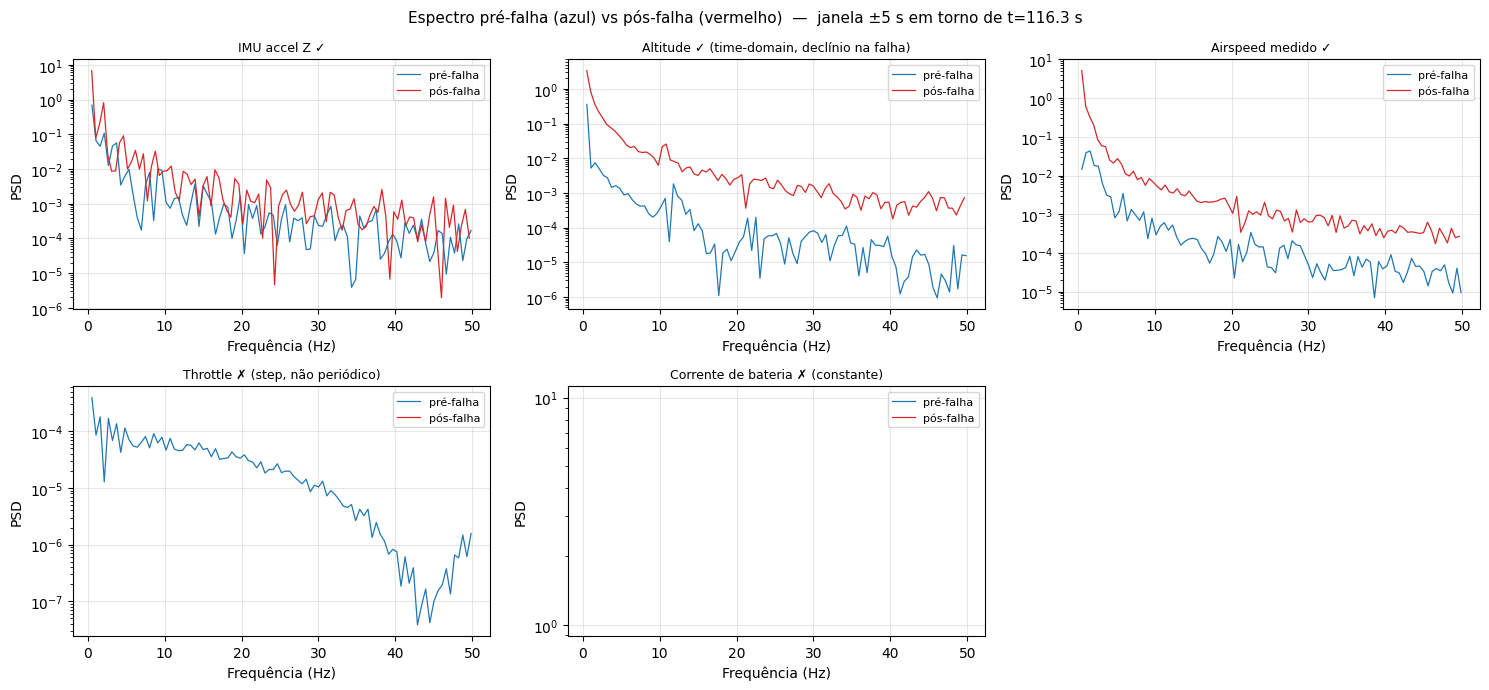

In [10]:
def plot_pre_post_failure_fft(
    df: pd.DataFrame,
    col: str,
    label: str,
    failure_time: float,
    window_seconds: float = 5.0,
    ax: plt.Axes | None = None,
) -> None:
    """Compara PSD do sinal antes e depois da falha."""
    dt = np.median(np.diff(df["%time"].values))
    fs = 1.0 / max(dt, 1e-6)

    pre = df[
        (df["%time"] >= failure_time - window_seconds) & (df["%time"] < failure_time)
    ][col].fillna(0).values.astype(float)

    post = df[
        (df["%time"] >= failure_time) & (df["%time"] < failure_time + window_seconds)
    ][col].fillna(0).values.astype(float)

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 3))

    for segment, name, color in [(pre, "pré-falha", "tab:blue"), (post, "pós-falha", "tab:red")]:
        if len(segment) < 10:
            continue
        freqs, psd = periodogram(segment - segment.mean(), fs=fs)
        max_freq = min(fs / 4, 50.0)
        mask = (freqs > 0) & (freqs <= max_freq)
        ax.semilogy(freqs[mask], psd[mask], label=name, color=color, linewidth=0.9)

    ax.set_title(label, fontsize=9)
    ax.set_xlabel("Frequência (Hz)")
    ax.set_ylabel("PSD")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)


if failure_time is not None:
    # Mostra os sinais selecionados + corrente de bateria (rejeitada) para contraste
    # Altitude está nos selecionados pois decai monotonicamente na falha
    comparison_signals = [
        (find_col(df_preprocessed, "linear_acceleration.z"),  "IMU accel Z ✓"),
        (find_col(df_preprocessed, "mag_field.magnetic.z"),   "Magnetômetro Z ✓"),
        (find_col(df_preprocessed, "global_field.altitude"),  "Altitude ✓ (time-domain, declínio na falha)"),
        (find_col(df_preprocessed, "airspeed_field.measured"),"Airspeed medido ✓"),
        (find_col(df_preprocessed, "vfr_hud_field.throttle"), "Throttle ✗ (step, não periódico)"),
        (find_col(df_preprocessed, "battery_field.current"),  "Corrente de bateria ✗ (constante)"),
    ]
    comparison_signals = [(col, lbl) for col, lbl in comparison_signals if col is not None]

    n = len(comparison_signals)
    ncols = min(n, 3)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
    axes = np.array(axes).flatten()

    fig.suptitle(
        f"Espectro pré-falha (azul) vs pós-falha (vermelho)  —  janela ±{5} s em torno de t={failure_time:.1f} s",
        fontsize=11,
    )

    for ax, (col, label) in zip(axes, comparison_signals):
        plot_pre_post_failure_fft(df_preprocessed, col, label, failure_time, ax=ax)

    # Oculta axes extras
    for ax in axes[len(comparison_signals):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("Falha não detectada — skipping comparação pré/pós falha.")

### Métricas espectrais: entropia e razão de alta frequência

Para quantificar a diferença espectral entre os grupos:

- **Entropia espectral normalizada** [0–1]: baixa → energia concentrada em poucas frequências
  (pico de vibração do motor); alta → energia espalhada (ruído).
- **Razão de alta frequência**: fração da potência total na metade superior do espectro.
  Vibração mecânica do motor tende a elevar esse valor.

Os sinais selecionados (azul) devem se destacar dos rejeitados (cinza) em ao menos uma dessas métricas.

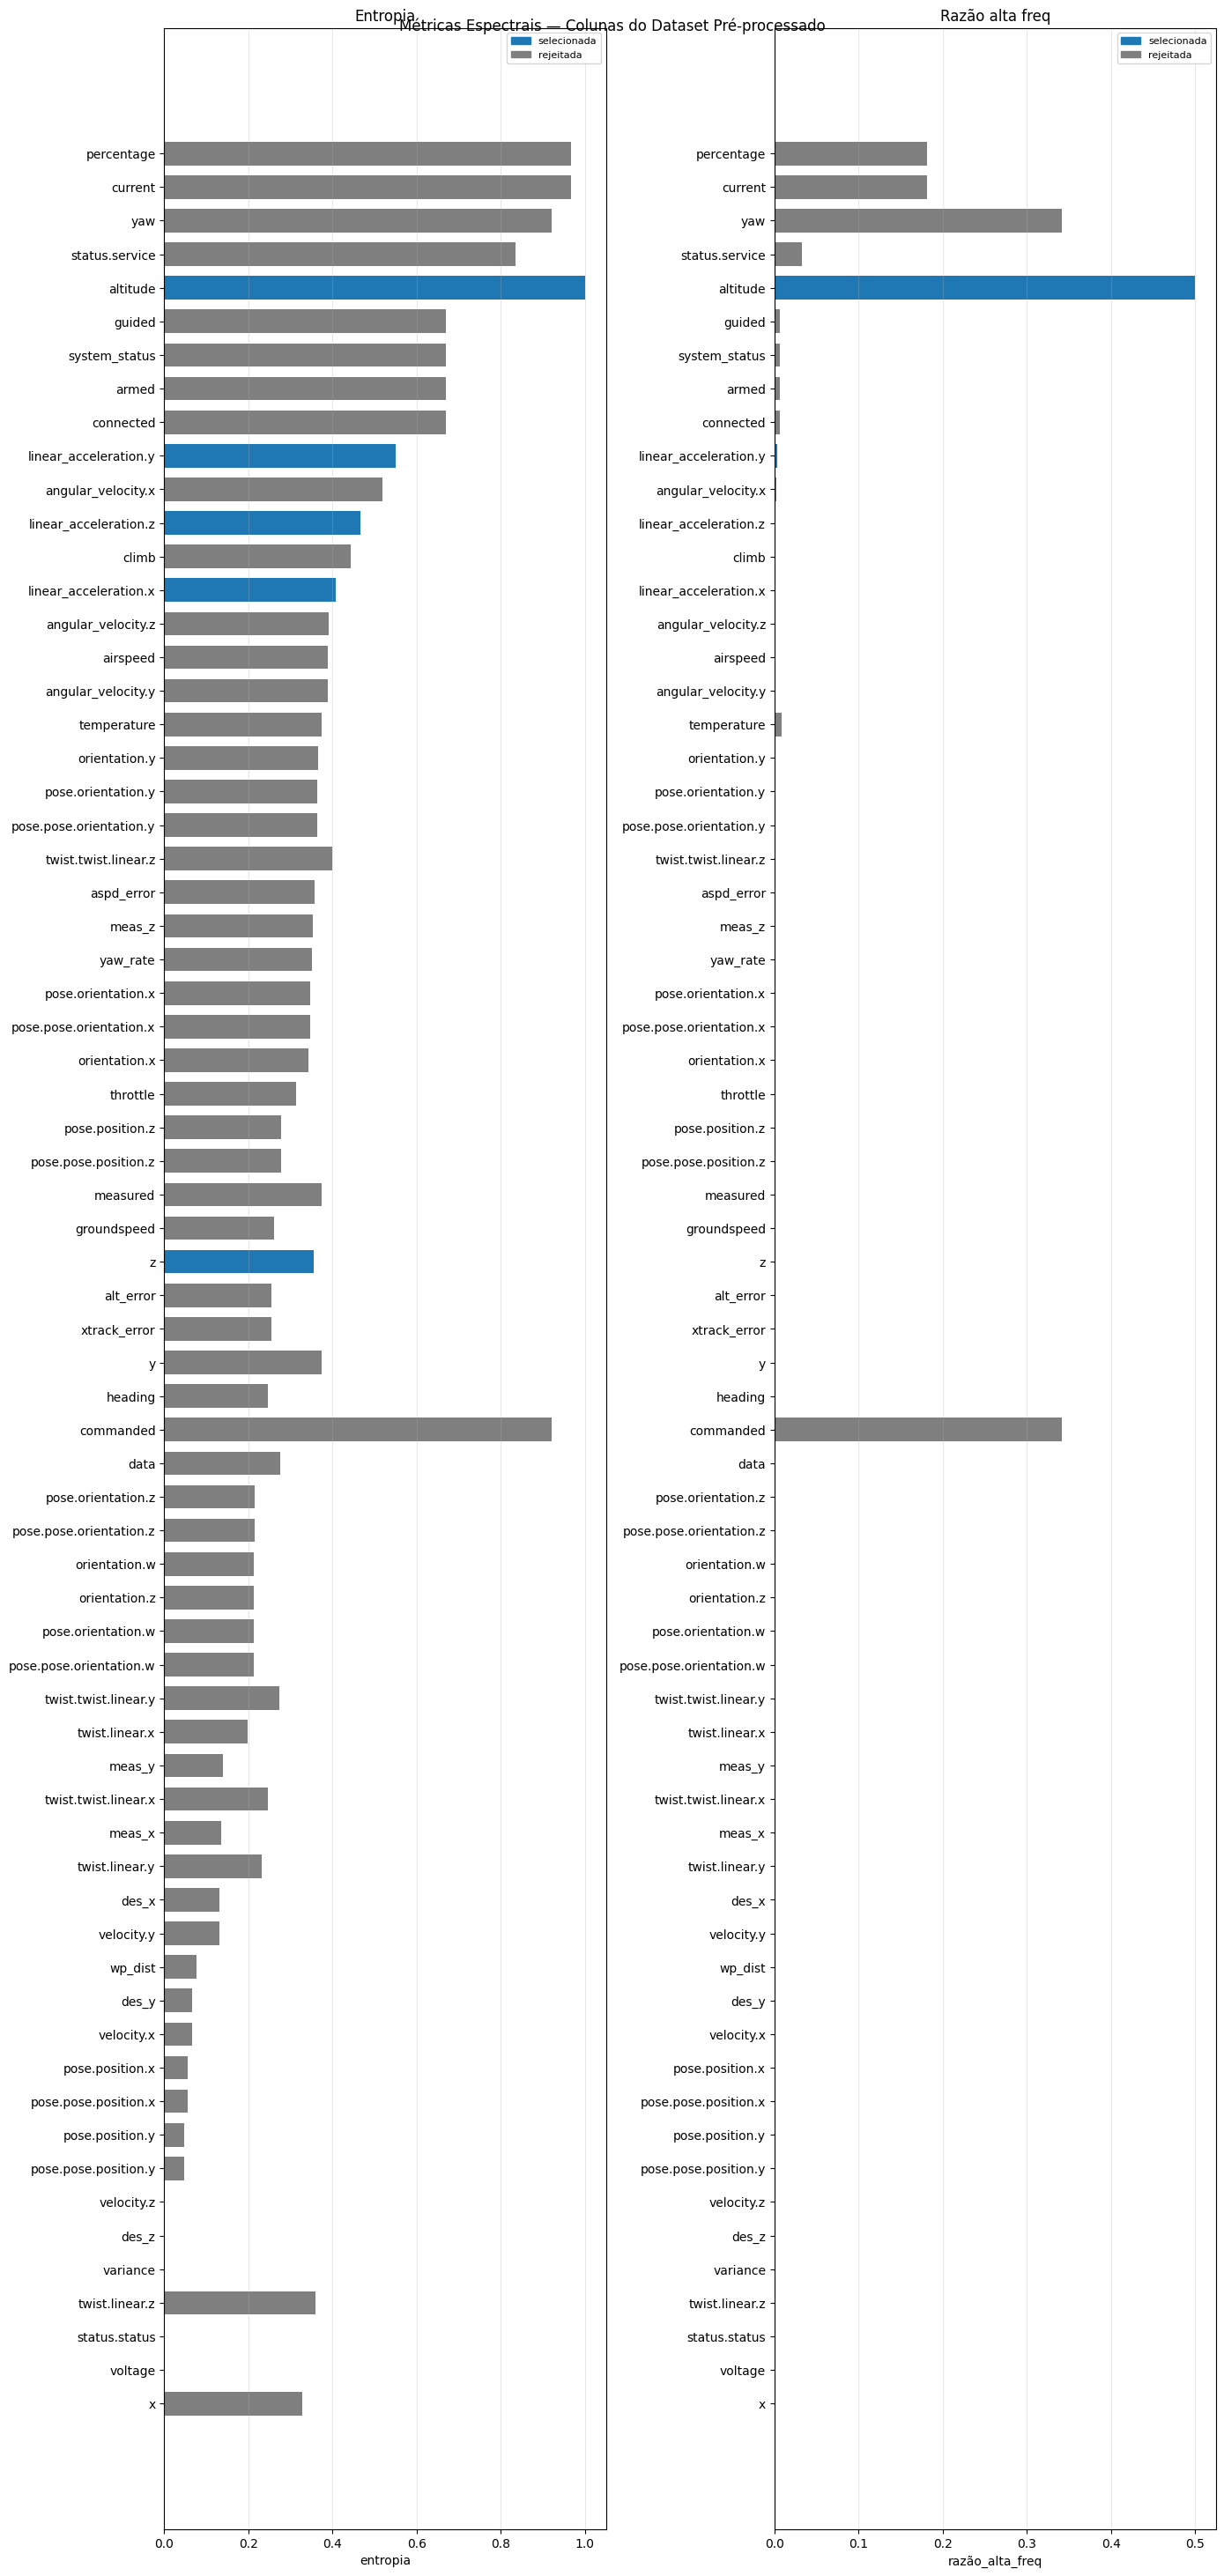

In [15]:
def spectral_metrics(df: pd.DataFrame, col: str) -> dict:
    """Calcula entropia normalizada e razão de alta frequência do sinal."""
    dt = np.median(np.diff(df["%time"].values))
    fs = 1.0 / max(dt, 1e-6)
    signal = df[col].fillna(0).values.astype(float)
    freqs, psd = periodogram(signal - signal.mean(), fs=fs)
    psd = psd[1:]  # remove DC
    total = psd.sum() + 1e-12
    p_norm = psd / total
    entropy = float(-np.sum(p_norm * np.log(p_norm + 1e-12)) / np.log(len(p_norm) + 1))
    mid = len(psd) // 2
    high_ratio = float(psd[mid:].sum() / total)
    return {"entropia": round(entropy, 4), "razão_alta_freq": round(high_ratio, 4)}


numeric_cols = [c for c in df_preprocessed.columns if c != "%time"]
rows = []
for col in numeric_cols:
    m = spectral_metrics(df_preprocessed, col)
    matched = [p for p in FFT_RELEVANT_PATTERNS if p in col]
    rows.append({
        "nome_curto": col.split("_field.")[-1].split("-")[-1],
        "selecionada": bool(matched),
        **m,
    })

df_metrics = pd.DataFrame(rows).sort_values("entropia")

fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(df_metrics) * 0.28)))

for ax, metric in zip(axes, ["entropia", "razão_alta_freq"]):
    colors = ["tab:blue" if sel else "tab:gray" for sel in df_metrics["selecionada"]]
    ax.barh(df_metrics["nome_curto"], df_metrics[metric], color=colors, height=0.7)
    ax.set_xlabel(metric)
    ax.set_title(metric.replace("_", " ").capitalize())
    ax.grid(True, alpha=0.3, axis="x")
    from matplotlib.patches import Patch
    ax.legend(
        handles=[
            Patch(color="tab:blue", label="selecionada"),
            Patch(color="tab:gray", label="rejeitada"),
        ],
        fontsize=8,
    )

plt.suptitle("Métricas Espectrais — Colunas do Dataset Pré-processado", fontsize=12)
plt.tight_layout()
plt.show()

## Passo 4 — Aplicação da seleção FFT

`select_fft_features` mantém apenas colunas cujo nome contém ao menos um padrão de
`FFT_RELEVANT_PATTERNS`. Os padrões são configuráveis em `conf/base/parameters.yml`.

In [16]:
df_fft_ready = select_fft_features(df_preprocessed)

print(f"Colunas antes da seleção:  {df_preprocessed.shape[1]}")
print(f"Colunas após seleção FFT:  {df_fft_ready.shape[1]}")
print(f"Removidas:                 {df_preprocessed.shape[1] - df_fft_ready.shape[1]}")
print()
print("=== Padrões e colunas correspondentes ===")
for pat in FFT_RELEVANT_PATTERNS:
    matches = [c.split("_field.")[-1] for c in df_fft_ready.columns if pat in c]
    status = "✓" if matches else "✗  (sem correspondência — verifique o nome do tópico ROS)"
    print(f"  {status}  [{pat}] → {matches}")

Colunas antes da seleção:  107
Colunas após seleção FFT:  11
Removidas:                 96

=== Padrões e colunas correspondentes ===
  ✓  [imu-data_field.linear_acceleration] → ['linear_acceleration.x', 'linear_acceleration.y', 'linear_acceleration.z']
  ✓  [mag_field.magnetic] → ['x', 'y', 'z']
  ✓  [airspeed_field.measured] → ['measured']
  ✓  [global_field.altitude] → ['altitude', 'altitude']
  ✓  [failure_status] → ['data']


## Resultado

O DataFrame `df_fft_ready` é o que a pipeline `fft_ingestion` salva em `data/02_intermediate/fft_ready/`.

**Redução:** ~50–60 colunas → ~9 colunas (3 IMU + 3 mag + airspeed + altitude + label)

Todos os sinais retidos possuem mecanismo físico de periodicidade diretamente ligada ao motor,
com exceção da **altitude** — incluída como única feature time-domain, pois declina monotonicamente
na falha de motor e complementa a assinatura espectral dos demais sinais.

A corrente de bateria foi removida por ser constante ao longo do tempo neste dataset (sem variação útil para o modelo).

---
**Próximo:** `01_01_data_preparation_fft.ipynb` → renaming e limpeza do dataset `fft_ready_flights`.

In [17]:
print(f"Shape final: {df_fft_ready.shape}")
print(f"Duração do voo: {df_fft_ready['%time'].max():.1f} s")
df_fft_ready.head(3)

Shape final: (26183, 11)
Duração do voo: 132.4 s


,%time,carbonZ_2018-07-18-15-53-31_1_engine_failure-failure_status-engines_field.data,carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-global_field.altitude,carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-imu-data_field.linear_acceleration.x,carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-imu-data_field.linear_acceleration.y,carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-imu-data_field.linear_acceleration.z,carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-imu-mag_field.magnetic_field.x,carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-imu-mag_field.magnetic_field.y,carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-imu-mag_field.magnetic_field.z,carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-nav_info-airspeed_field.measured,carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-setpoint_raw-target_global_field.altitude
0,0.040093,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
1,0.044453,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.666935,380.350006
2,0.045652,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.666935,380.350006


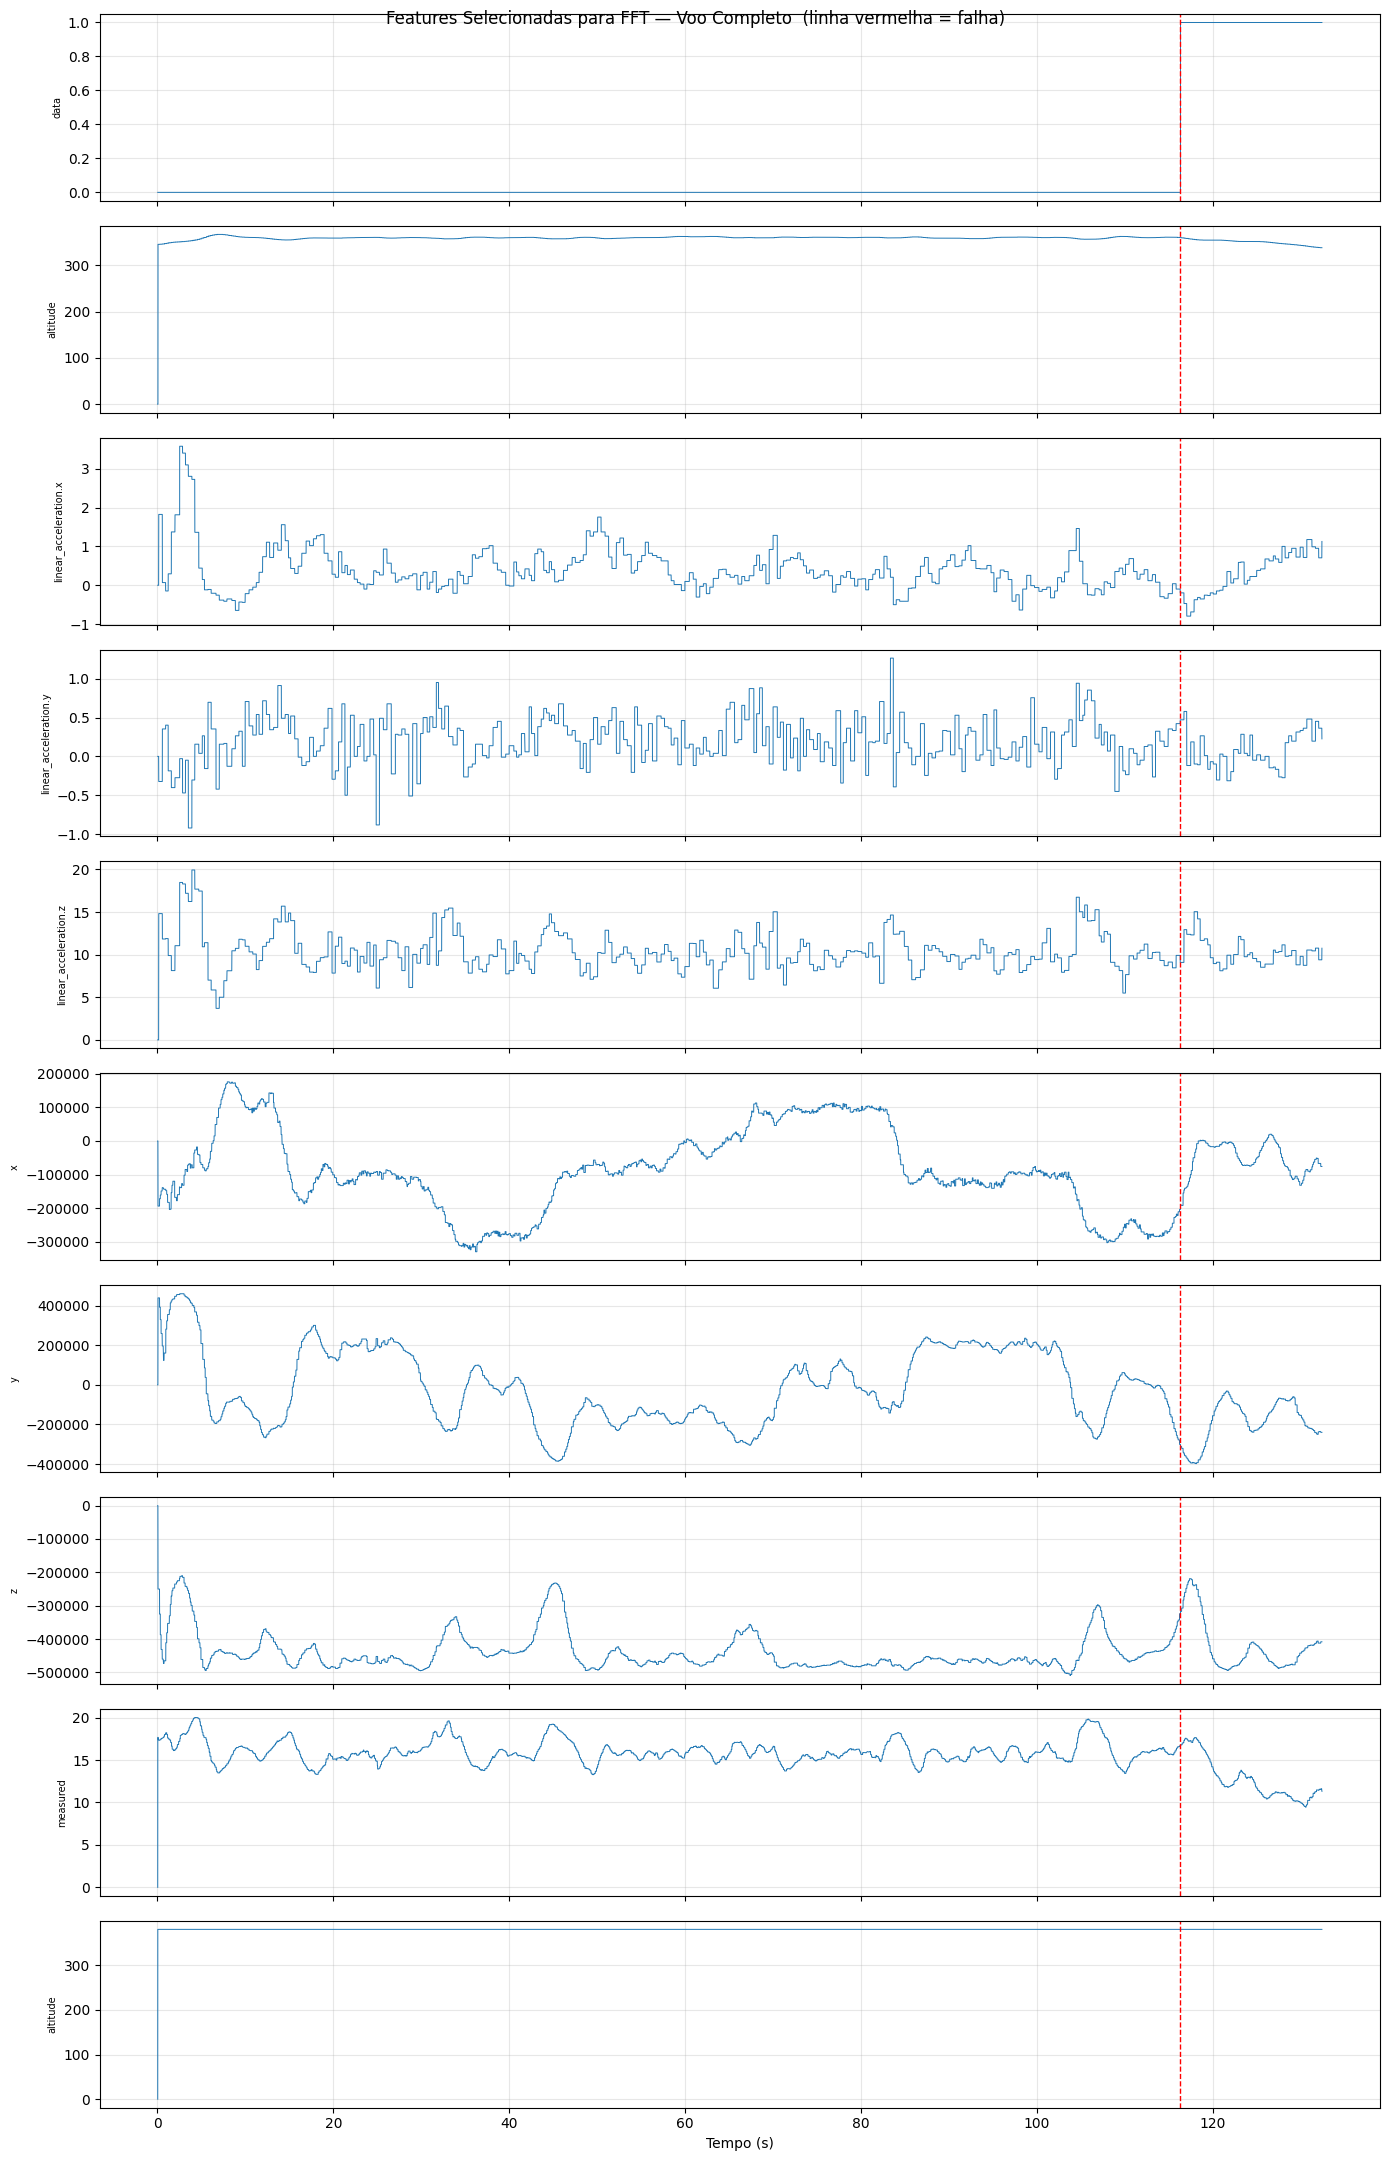

In [18]:
# Visualização de todas as colunas selecionadas no voo completo
cols_to_plot = [c for c in df_fft_ready.columns if c != "%time"]
n = len(cols_to_plot)

fig, axes = plt.subplots(n, 1, figsize=(14, 2.2 * n), sharex=True)
if n == 1:
    axes = [axes]

for ax, col in zip(axes, cols_to_plot):
    label = col.split("_field.")[-1]
    ax.plot(df_fft_ready["%time"], df_fft_ready[col], linewidth=0.7, color="tab:blue")
    if failure_time is not None:
        ax.axvline(failure_time, color="red", linestyle="--", linewidth=1.0)
    ax.set_ylabel(label, fontsize=7)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Tempo (s)")
plt.suptitle("Features Selecionadas para FFT — Voo Completo  (linha vermelha = falha)", fontsize=12)
plt.tight_layout()
plt.show()